In [111]:
import os
import sys
# set root path so that all modules can be called
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('TkAgg')
%matplotlib inline

import numpy as np

# data
1. `generator.py`
2. `dataset.py`

# 

In [77]:
from data.dataset import FBmDataset
from data.generator import FractionalBrownianMotionGenerator

fbm_generator = FractionalBrownianMotionGenerator(T = 10, dt = 1, method="davies-harte", seed=2)
X, y = fbm_generator.generate_dataset(n_samples=13, 
                                      H_range=(0,1,0,9),
                                      H_values=None)

fbm_dataset = FBmDataset(X, y, normalize="zscore")

print("Shape of inputs:  ",fbm_dataset.X.shape) # must be (n_samples, T)
print("Shape of targets: ",fbm_dataset.y.shape) # must b  (n_samples, 1)


Shape of inputs:   (13, 10)
Shape of targets:  (13,)


In [85]:

np.random.seed(4)

X = np.array([np.random.randint(0, 10, size=24) for _ in range(11)])
# print(X)
print("Shape of X: ", X.shape)

y = np.array(np.random.random(size=11),)

# print(y)
print("Shape of y: ", y.shape)

rng = np.random.default_rng(3)
n = len(y)

stratify_bins = 3
bins = np.linspace(y.min(), y.max() + 1e-8, stratify_bins+1)
bin_idx = np.digitize(y, bins) - 1

print("Bin index: ", bin_idx) # each y ha a bin label

train_idx, val_idx, test_idx = [], [], []

for b in range(stratify_bins):

    idx = np.where(bin_idx == b)[0]
    print(idx)
    rng.shuffle(idx)
    n_b = len(idx)
    n_val = int(round(n_b * 0.2))
    n_test = int(round(n_b * 0.2))
    val_idx.extend(idx[:n_val])
    test_idx.extend(idx[n_val:n_val + n_test])
    train_idx.extend(idx[n_val + n_test:])

Shape of X:  (11, 24)
Shape of y:  (11,)
Bin index:  [1 2 0 2 2 2 0 0 1 0 0]
[ 2  6  7  9 10]
[0 8]
[1 3 4 5]


# utils 
`preprocessing.py`

In [89]:
from utils.preprocessing import extract_features

X_features = extract_features(X, 3)
print(X_features.shape)

#only X is expanded, the target y remain same

(11, 6)


# Phase 1 - 2
### 1.  Generating data using simulations
### 2.  Visualize the trajectories

[1/8] Generating 100 fBm trajectories of length 256...
  Train: 68  Val: 16  Test: 16
[2/8] Plotting sample trajectories...


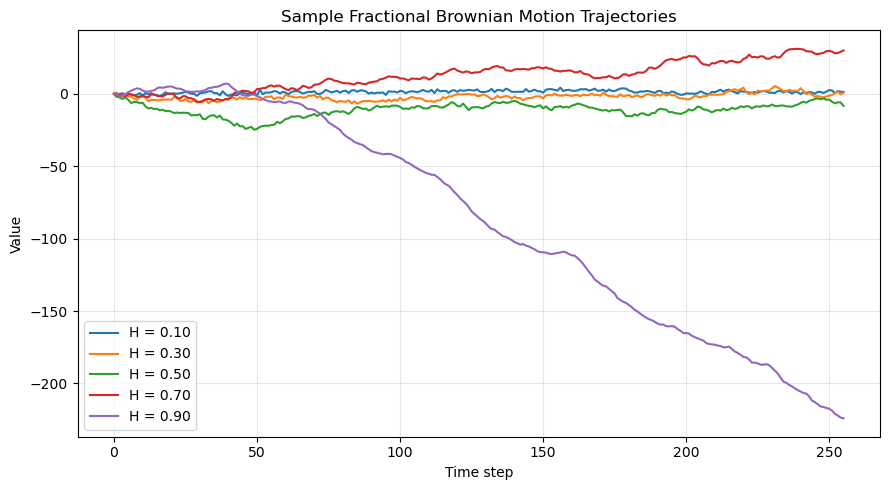

In [112]:
# ------------------------------------------------------------------
# 1. Generate dataset
# ------------------------------------------------------------------
n_samples = 100
T = 256
seed = 1234

from data.dataset import train_val_test_split 


print(f"[1/8] Generating {n_samples} fBm trajectories of length {T}...")
gen = FractionalBrownianMotionGenerator(T=T, method="davies-harte", seed=seed)
X, y = gen.generate_dataset(n_samples=n_samples, H_range=(0.1, 0.9))

(X_tr, y_tr), (X_val, y_val), (X_te, y_te) = train_val_test_split(
    X, y, val_frac=0.15, test_frac=0.15, seed=seed
)
print(f"  Train: {len(y_tr)}  Val: {len(y_val)}  Test: {len(y_te)}")

# ------------------------------------------------------------------
# 2. Visualize sample trajectories
# ------------------------------------------------------------------
from evaluation.plots import plot_sample_paths
print("[2/8] Plotting sample trajectories...")
fig = plot_sample_paths(gen, save_path=None)
plt.show()

# Phase 3
### Train baseline models

In [114]:
# ------------------------------------------------------------------
# 3. Baseline model
# ------------------------------------------------------------------

from models.baseline import BaselineHurstRegressor
from evaluation.metrics import summarize

print("[3/8] Training baseline (Random Forest on handcrafted features)...")

results = {}
baseline = BaselineHurstRegressor(kind="random_forest")
baseline.fit(X_tr, y_tr)
base_preds = baseline.predict(X_te)
results["Linear/RF Baseline"] = (base_preds, y_te)
print("  Baseline test metrics:", summarize(y_te, base_preds))

print("[3/8] Training baseline (Random Forest on handcrafted features)...")

results = {}
baseline = BaselineHurstRegressor(kind="linear")
baseline.fit(X_tr, y_tr)
base_preds = baseline.predict(X_te)
results["Linear/RF Baseline"] = (base_preds, y_te)
print("  Baseline test metrics:", summarize(y_te, base_preds))

[3/8] Training baseline (Random Forest on handcrafted features)...
  Baseline test metrics: {'MAE': 0.040943170281442585, 'RMSE': 0.055283313750430836, 'R2': 0.948691691362995}
[3/8] Training baseline (Random Forest on handcrafted features)...
  Baseline test metrics: {'MAE': 0.04855474542220631, 'RMSE': 0.06274362968339807, 'R2': 0.9339095298301847}


# Phase 4 
#### LSTM model

[4/8] Training LSTM...


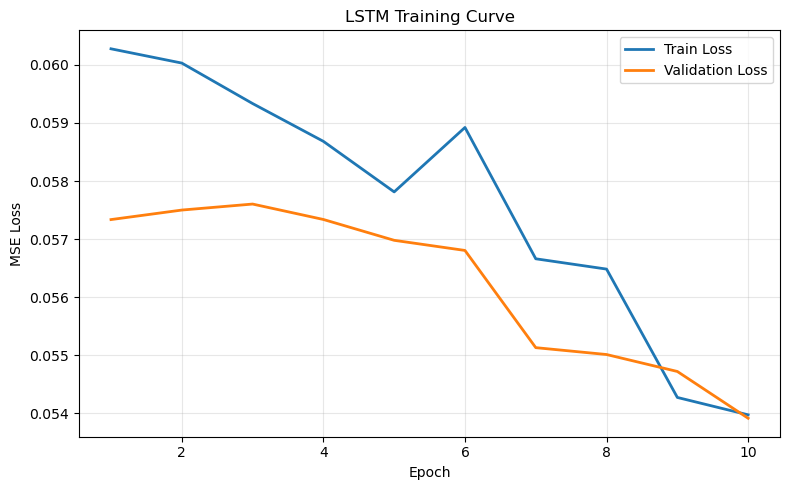

In [116]:
# ----------------------------------------------------------
# 4. LSTM
# ------------------------------------------------------------------

print("[4/8] Training LSTM...")

from models.lstm import LSTMHurstRegressor
from training.train_lstm import train_model
from training.trainer import predict
from evaluation.plots import plot_loss_curves

epochs = 10
batch_size = 12
lr = 1e-3


train_ds = FBmDataset(X_tr, y_tr, normalize="zscore")
val_ds = FBmDataset(X_val, y_val, normalize="zscore")
test_ds = FBmDataset(X_te, y_te, normalize="zscore")

lstm = LSTMHurstRegressor(hidden_size=128, num_layers=2, dropout=0.2)
lstm, lstm_history = train_model(
    lstm, train_ds, val_ds, epochs=epochs, batch_size=batch_size, lr=lr
)
lstm_preds, lstm_targets = predict(lstm, test_ds)
results["LSTM"] = (lstm_preds, lstm_targets)
print("  LSTM test metrics:", summarize(lstm_targets, lstm_preds))

plot_loss_curves(
    lstm_history["train_loss"], lstm_history["val_loss"],
    title="LSTM Training Curve",
)
plt.show()


# Phase 5
### Transformer model

[5/8] Training Transformer...
Using:  cpu
Epoch   1/10 | train_loss=0.06581 | val_loss=0.05606
Epoch   5/10 | train_loss=0.06052 | val_loss=0.05718
Epoch  10/10 | train_loss=0.05999 | val_loss=0.05758
  Transformer test metrics: {'MAE': 0.21227309107780457, 'RMSE': 0.24584142863750458, 'R2': -0.014634671068436411}


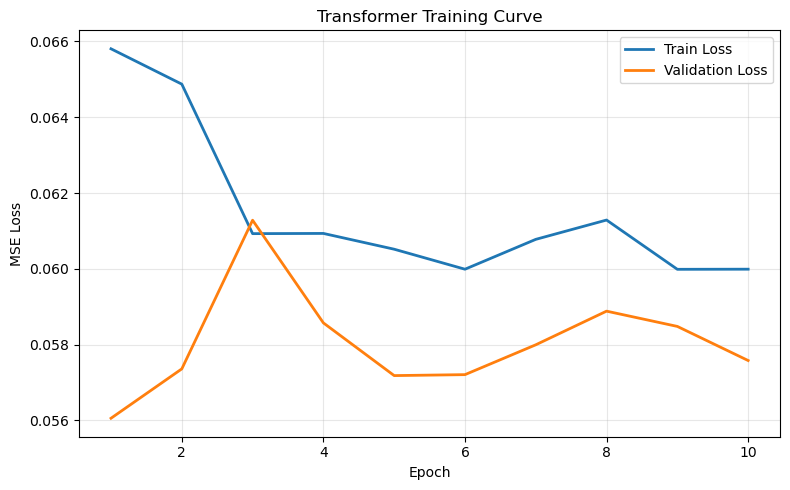

In [118]:
# ------------------------------------------------------------------
# 5. Transformer
# ------------------------------------------------------------------

from models.transformer import TransformerHurstRegressor


epochs = 10
batch_size = 12
lr = 1e-3



print("[5/8] Training Transformer...")
transformer = TransformerHurstRegressor(
d_model=64, nhead=4, num_layers=3, dim_feedforward=256,
dropout=0.1, use_cls_token=True, max_len=T,
)
transformer, tr_history = train_model(
transformer, train_ds, val_ds, epochs=epochs, batch_size=batch_size, lr=lr
)
tr_preds, tr_targets = predict(transformer, test_ds)
results["Transformer"] = (tr_preds, tr_targets)
print("  Transformer test metrics:", summarize(tr_targets, tr_preds))

plot_loss_curves(
tr_history["train_loss"], tr_history["val_loss"],
title="Transformer Training Curve")

plt.show()

# Phase 6
### Summarize data

In [119]:
# ------------------------------------------------------------------
# 6. Evaluation (global + sliced)
# ------------------------------------------------------------------

from evaluation.metrics import slice_metrics

print("[6/8] Evaluating all models...")
for name, (preds, targets) in results.items():
    print(f"\n--- {name} ---")
    print("Global:", summarize(targets, preds))
    print("By H range:")
    for slice_name, m in slice_metrics(targets, preds).items():
        print(f"  {slice_name}: {m}")

[6/8] Evaluating all models...

--- Linear/RF Baseline ---
Global: {'MAE': 0.04855474542220631, 'RMSE': 0.06274362968339807, 'R2': 0.9339095298301847}
By H range:
  low_memory (H<0.4): {'MAE': 0.040563321429579226, 'RMSE': 0.045504690813091414, 'R2': 0.7454284901504578, 'n': 7}
  brownian (0.4<=H<0.6): {'MAE': 0.09619603733176756, 'RMSE': 0.11328020879831813, 'R2': -30.729550631995394, 'n': 3}
  persistent (H>=0.6): {'MAE': 0.03405742745882395, 'RMSE': 0.040817181299507684, 'R2': 0.7194116335411791, 'n': 6}

--- LSTM ---
Global: {'MAE': 0.2047586888074875, 'RMSE': 0.2283347249031067, 'R2': 0.12472704303487148}
By H range:
  low_memory (H<0.4): {'MAE': 0.22709938883781433, 'RMSE': 0.24832658469676971, 'R2': -6.581303470397047, 'n': 7}
  brownian (0.4<=H<0.6): {'MAE': 0.07957194000482559, 'RMSE': 0.08778496086597443, 'R2': -18.05443180620605, 'n': 3}
  persistent (H>=0.6): {'MAE': 0.24128790199756622, 'RMSE': 0.2514646351337433, 'R2': -9.649701242808309, 'n': 6}

--- Transformer ---
Glob

# Phase 7
### Plot evaluations

[7/8] Producing prediction/error plots...


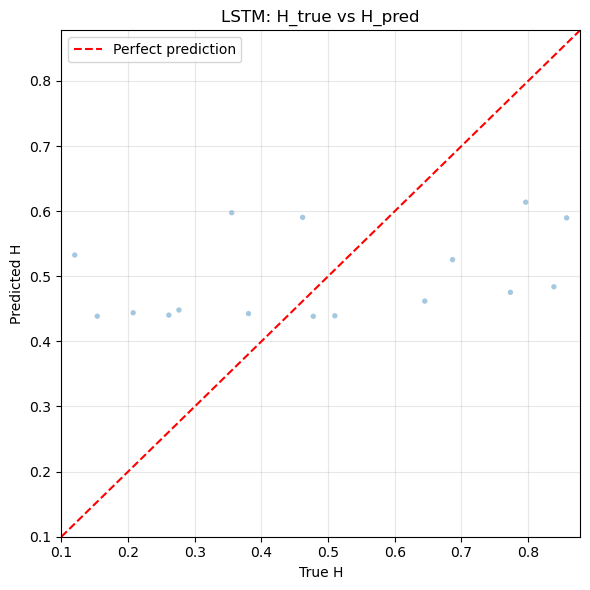

In [123]:
# ------------------------------------------------------------------
# 7. Plots (best deep model = lowest MAE among LSTM/Transformer)
# ------------------------------------------------------------------
from evaluation.plots import plot_prediction_scatter

print("[7/8] Producing prediction/error plots...")

plot_prediction_scatter(
    lstm_targets, lstm_preds, title="LSTM: H_true vs H_pred")

plt.show()

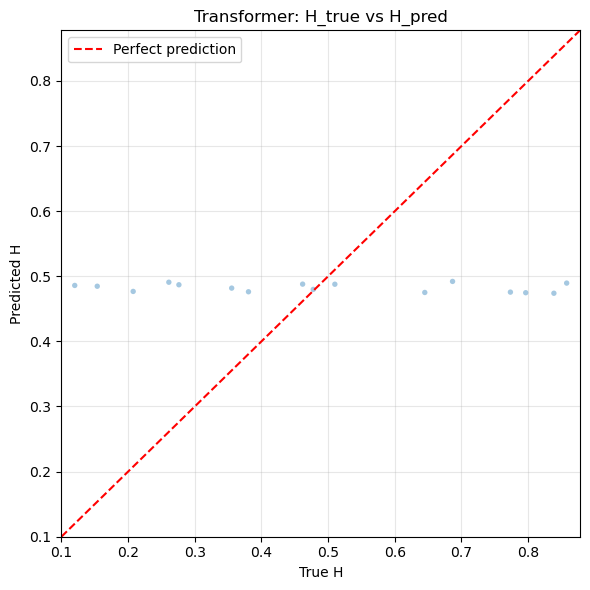

In [125]:

plot_prediction_scatter(
    tr_targets, tr_preds, title="Transformer: H_true vs H_pred")
plt.show()

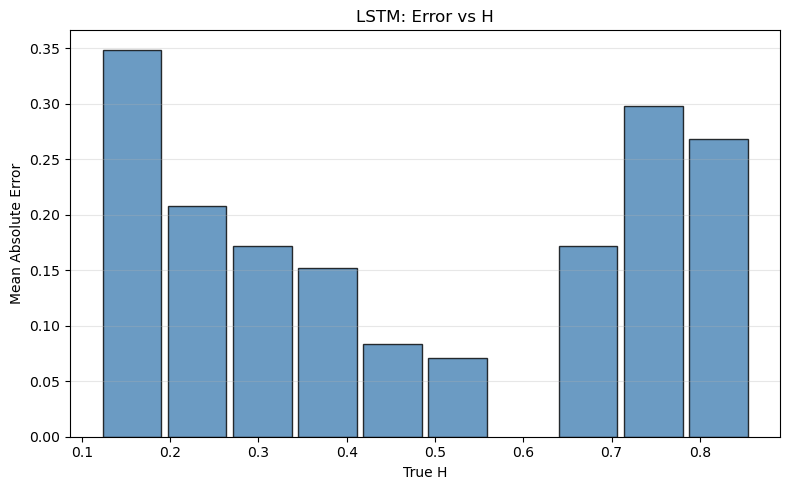

In [128]:
from evaluation.plots import plot_error_vs_H
plot_error_vs_H(
    lstm_targets, lstm_preds, title="LSTM: Error vs H")
plt.show()

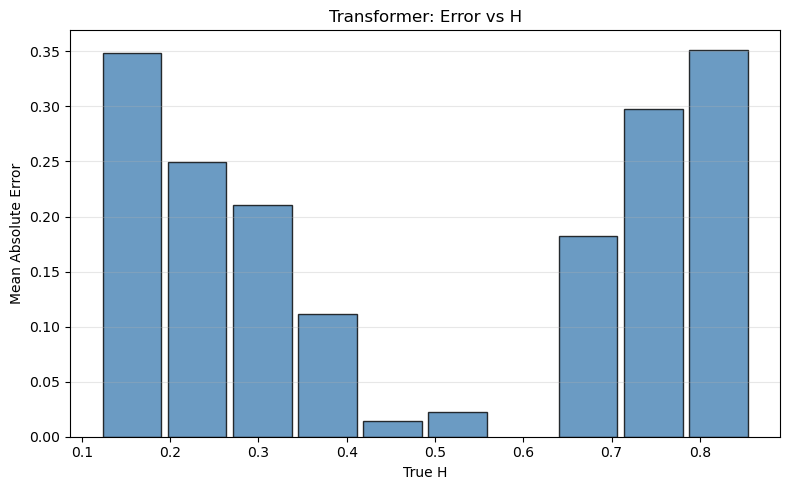

In [129]:
plot_error_vs_H(
    tr_targets, tr_preds, title="Transformer: Error vs H")
plt.show()

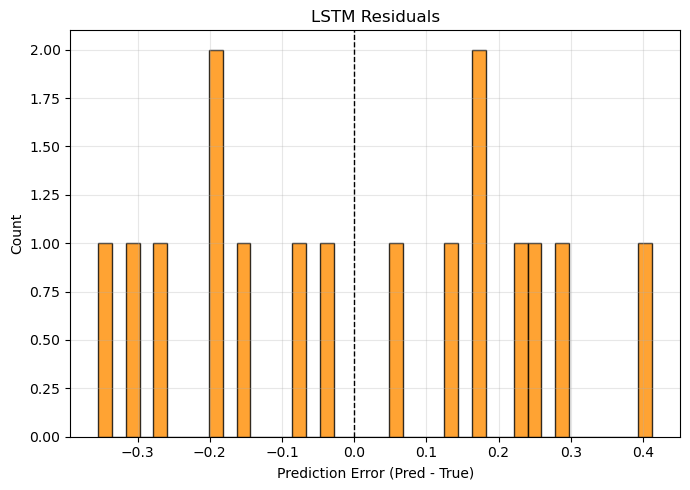

In [130]:
from evaluation.plots import plot_residual_distribution
plot_residual_distribution(
    lstm_targets, lstm_preds, title="LSTM Residuals",
)
plt.show()


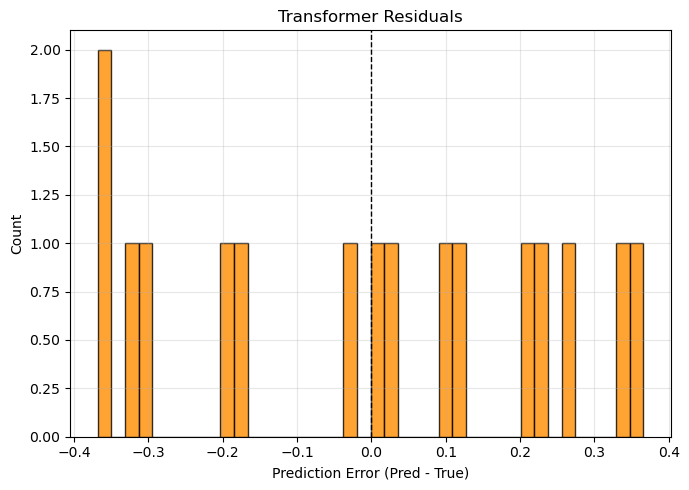

In [131]:

plot_residual_distribution(
    tr_targets, tr_preds, title="Transformer Residuals",
)
plt.show()

# Phase 8

### comparison between Deep learning and ML models

In [132]:
print("\n[8/8] Final comparison table")
print(f"{'Model':<20}{'MAE':>10}{'RMSE':>10}{'R2':>10}")
for name, (preds, targets) in results.items():
    m = summarize(targets, preds)
    print(f"{name:<20}{m['MAE']:>10.4f}{m['RMSE']:>10.4f}{m['R2']:>10.4f}")



[8/8] Final comparison table
Model                      MAE      RMSE        R2
Linear/RF Baseline      0.0486    0.0627    0.9339
LSTM                    0.2048    0.2283    0.1247
Transformer             0.2123    0.2458   -0.0146
